# Notebook 1: Does a protein cluster?

In [1]:
%pip install git+https://github.com/bobiac/bobiac-tools.git
%pip install matplotlib
%pip install numpy
%pip install scikit-image
%pip install scipy
%pip install tifffile
%pip install imagecodecs
%pip install pandas
%pip install seaborn

## Overview

In this notebook, we will learn how to assess whether individual proteins are clustering.

### Dataset
Our data consists of fluorescence images with five channels:
| Channel | Staining | Staining Description |
|---------|---------|----------------|
| 0 | Hoechst | Nuclear stain |
| 1 | Phalloidin | F-actin stain; whole cell marker |
| 2 | Protein A | Spot pattern |
| 3 | Protein B | Spot pattern |
| 4 | Protein C | Spot pattern |

The data for this exercise is the same as used for the classic segmentation, deep learning segmentation and spot detection exercises and can be downloaded [here](https://github.com/bobiac/bobiac-book/releases/download/data-bobiac-2026/04_05_06_07_seg_and_spot.zip). From the previous segmentation exercises you should have a collection of labelled masks for the cells, and coordinates for spots. If not you can download them from [here](https://github.com/bobiac/bobiac-book/releases/download/data-bobiac-2026/04_05_06_07_seg_and_spot_labels_and_spots_coords.zip).


***

## 0. Importing libraries

***

## 2. Load image, mask and spot table
First, we load all the data that we will need for this notebook.

### Visually inspect the images, masks and spots
To be sure that the data we are working with is corrects, we visualise it here.

Using the `focus` attribute in `overlay` we can zoom in to view single objects.

***

## 3. Make An Analysis Plan

### Question
Are the spots clustered?

### Approach 
To answer this question, we need to first define a reference for comparison. A common comparison is **complete spatial randomness (CSR)** (i.e., a fully random distribution of points). We can then define a metric that measures if a collection of points are clustered, and then use this metric to compare our dataset collection of points to a collection of random points. 

### Metric for Clustering
Here, we use the **average distance of each point to its nearest neighbour** as the metric for clustering.

### Workflow

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein dataset**.

#### 2. Measure the nearest neighbor distance
For each spot, identify the closest spot within a cell and measure the distance. 

#### 3. Calculate the average nearest neighbour distance
For each cell, calculate the average nearest neighbor distance for a spot.  

#### 4. Calculate the Clark-Evans Index
The Clark-Evans Index is a ratio between the average nearest neighbour distances for the **protein dataset** and the **random dataset**. This index represents how random or clustered the dot protein distribution is.
    - **Ratio = 1:** The distribution is random 
    - **Ratio > 1:** The distribution is clusered

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.


To start, we focus on **Protein A (Channel 2).**

***

## 4. Assemble the Protein Dataset and the Random Dataset

### Protein Dataset: Map spots to cells and count spots per cell
We need to know how many points are within each cell to place the same number of random points in the next step. If we would generate more or less random points, we would artificially measure clustering or dispersion.

First we generate a dataframe for the cells by using `regionprops_table`.

Then we count the spots per cell (like in Exercise B: Nested Objects).

### Random Dataset: Generate random points
Let's generate our first set of random points. To make it more transparent, let's focus on a single cell first.

We can use a pre-written function to generate the random points. In short, what it does is:
* It calculates the bounding box of the cell (the box that touches the edge of the cell at every side).
* It draws random points inside that box and tests if they fall within the cell.
    * If not, the point is discarded.
    * If it is within the cell it is kept.
This sequence is repeated until the cell contains the specified number of points.

This procedure is necessary since cells have irregular shapes.

In [70]:
# or use:
# from bobiac_tools import random_points_in_mask


def random_points_in_mask(mask: np.ndarray, cell_label: int, n: int) -> np.ndarray:
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)

Look up how many points are in our cell of interest.

Create the same number of random points inside that cell.

***

## 5. Calculate Nearest Neighbor Distances

### Identifying Neighbors: KD Trees
Now that we have two sets of points, our protein dataset and the random dataset as a control, we can find the nearest neighbour of every point and calculate the distance. To find neighbors, we will use a `KD tree`, a spatial partitioning algorithm that identities neighbours very effectively.

The syntax for the KD tree function is a bit strange at first: 
```python
KDtree(points_A).query(points_B, k=k)
```

- `KDTree(points_A)` builds the KD tree data structure. 
- `.query(points_B, k=k)` computes the distance to the nearest neighbors. It measures the distance from every point in `points_B` to the `k` nearest neighbours in `points_A`. If the two point sets are the same (like in our case), the first distance will be 0, since it is the distance from each point to itself.

We do the same for the random spots.

***

## 6. Calculate the Clark-Evans Index for the protein and random datasets

Now, let's calculate the mean nearest neighbour distances for both spot patterns and compare them using the Clark-Evans Index.

***

## 7. Repeat Steps 4-6 with Multiple Random Patterns

### Concept
A single random pattern as a control dataset is not a reliable comparison because a random pattern could be clustered by chance. To account for this possibility, we repeat this procedure with additional random patterns.

Can we trust this metric now? A little more, but it would be great to have a p-value. We can calculate the p-value by asking 'In what fraction of the runs was the observed NN distance smaller than random?'.

The fraction of `True`s in this list is our p-value. 

* Clustered spots → NND_observed is small → most simulations produce a larger NND → few simulations have NND_sim ≤ NND_obs → p close to 0
* Random spots → NND_observed is typical → roughly half the simulations fall below it → p ≈ 0.5

***

## 8. Repeat Measurements for All Cells

So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

### ✍️ Exercise: Summarise the per-cell clustering analysis as a function

To make processing individual cells simpler, we can summarise our above analysis in a function called `nn_dist`.
The function should have the following features:

**Parameters:**
* spots : (n, 2) numpy array
    Spot coordinates in (row, col) / (y, x) order.
* mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
* cell_id : int
    ID of the cell in mask that spots belong to.
* n_repeats : int
    Number of CSR simulations to run.

**Returns**
* spot_dist_avg : float
    Mean nearest-neighbor distance of the observed spots.
* rnd_dist_avg : float
    Mean of the per-simulation mean nearest-neighbor distances under CSR.
* clark_evans : float
    Clark-Evans index: spot_dist_avg / rnd_dist_avg.
* p_value : float
    Fraction of CSR simulations with mean NND <= spot_dist_avg.


***

## 9. Perform the Same Calculation on the Other Channels
Let's use the tools we developed above to see if the spots in the other channels.

**Protein B**

**Protein C**

It seems like **protein A is not clustered**, **protein B is clustering** and protein C is a little ambiguous. 

***

## 10. Measure the Length Scale of Clustering: Ripleys L Function
We know that Protein B is clustered compared to random. However, we don't know what scale the clustering is occurring on. 

A common method to investigate the length scales of spatial patterns is **Ripley's L function**. The idea is to calculate the density of spots around each spot for different radii and compare that to a random point pattern. The density of a random pattern is independent of the radius, while clustered points will exhibit higher density at shorter radii than longer ones. This way we can infer the average cluster size and distance between clusters.

Here, we only demonstrate the concept on the spot pattern of protein B in one cell. 

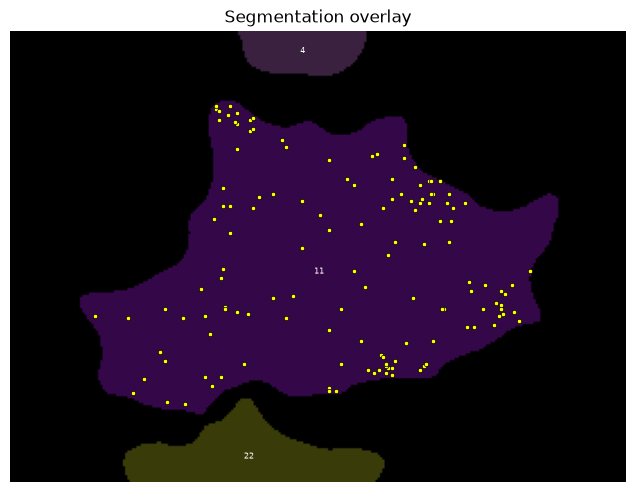

(<Figure size 800x586.081 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [94]:
spots = df_spots.loc[(df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)][
    ["y", "x"]
].to_numpy()
overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

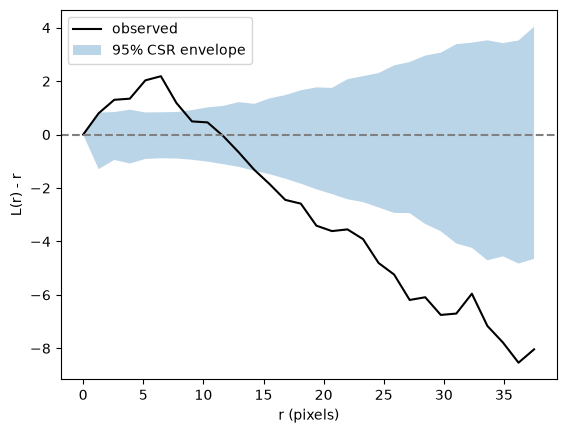

In [95]:
r_values, L_obs, L_sims = ripleys_l(spots, mask, cell_id=cell_id, n_repeats=200)

plt.plot(r_values, L_obs, color="black", label="observed")
plt.fill_between(
    r_values,
    np.percentile(L_sims, 2.5, axis=0),
    np.percentile(L_sims, 97.5, axis=0),
    alpha=0.3,
    label="95% CSR envelope",
)

plt.axhline(0, color="grey", linestyle="--")
plt.xlabel("r (pixels)")
plt.ylabel("L(r) - r")
plt.legend()

We observe clustering with scale 2-10 pixels, where the observed curve is above the 95% CSR envelope. Moreover, we see a corresponding dispersion from 15 pixels onward. This is because our random null distribution has the same number of points as the observed distribution.

## Conclusion
Here we have learned how to assess whether a spot pattern is clustered compared to random. Note the following:
* The metric we used to measure clustering (nearest neighbor distance) was a choice. Other metrics, such as number of spots in a certain radius, distance to k nearest neighbors, and many others, are valid. Can you think of a spot pattern where the nearest neighbor distance is not an appropriate metric?
* We chose a completely random spatial pattern as a null distribution. This was a choice. An equally valid option would have been to translate, rotate, etc., the spot pattern.
* The formalism with which we defined spatial relationships (KDTree / Euclidean distance nearest neighbor search) was a choice. An equally valid approach would have been to divide space using a Voronoi diagram, or to use the distance between cell membranes. 

All these choices need to be made with your scientific question in mind.